# TTC Delay Analysis: Where the Slowdowns Show Up

This notebook follows one year of TTC delay records alongside daily weather data. The story starts by cleaning the raw files, then looks for patterns by time, location, route, and weather before testing whether a simple model can flag longer delays.


## 1. Meet the Data

First, load the TTC delay records and the weather observations. A quick preview helps confirm what each file contains before changing anything.


In [1]:
import pandas as pd

delays = pd.read_csv("../data/ttc_delays.csv")
weather = pd.read_csv("../data/weather.csv")

print("Delays Data:")
print(delays.head())

print("\nWeather Data:")
print(weather.head())

Delays Data:
   _id        Date   Time        Day            Station   Code  Min Delay  \
0    1  2025-01-01  02:10  Wednesday   BATHURST STATION  MUSAN          5   
1    2  2025-01-01  02:30  Wednesday     DUNDAS STATION  MUIRS          0   
2    3  2025-01-01  02:32  Wednesday  BROADVIEW STATION  PUMST          0   
3    4  2025-01-01  02:58  Wednesday      KEELE STATION   EUSC          0   
4    5  2025-01-01  02:58  Wednesday    COXWELL STATION   SUAE          0   

   Min Gap Bound Line  Vehicle  
0        9     E   BD     5227  
1        0   NaN   YU        0  
2        0     E   BD        0  
3        0     W   BD     5293  
4        0   NaN   BD        0  

Weather Data:
   Longitude (x)  Latitude (y)    Station Name  Climate ID   Date/Time  Year  \
0         -79.63         43.68  TORONTO INTL A     6158731  2025-01-01  2025   
1         -79.63         43.68  TORONTO INTL A     6158731  2025-01-02  2025   
2         -79.63         43.68  TORONTO INTL A     6158731  2025-01-03 

In [2]:
print(delays.columns)
print(weather.columns)

Index(['_id', 'Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap',
       'Bound', 'Line', 'Vehicle'],
      dtype='str')
Index(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID',
       'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)',
       'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)',
       'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag',
       'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)',
       'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag',
       'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)',
       'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)',
       'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)',
       'Spd of Max Gust Flag'],
      dtype='str')


## 2. Prepare the Data

The raw column names use spaces, symbols, and mixed capitalization. Cleaning those names and creating date/time features makes the two datasets easier to join and analyze.


In [3]:
# Making a copy so we do not damage the original data
ttc = delays.copy()
weather_data = weather.copy()

# Clean column names: lowercase + replace spaces with underscores
ttc.columns = ttc.columns.str.lower().str.replace(" ", "_")
weather_data.columns = weather_data.columns.str.lower().str.replace(" ", "_").str.replace("/", "_")

print(ttc.columns)
print(weather_data.columns)

Index(['_id', 'date', 'time', 'day', 'station', 'code', 'min_delay', 'min_gap',
       'bound', 'line', 'vehicle'],
      dtype='str')
Index(['longitude_(x)', 'latitude_(y)', 'station_name', 'climate_id',
       'date_time', 'year', 'month', 'day', 'data_quality', 'max_temp_(°c)',
       'max_temp_flag', 'min_temp_(°c)', 'min_temp_flag', 'mean_temp_(°c)',
       'mean_temp_flag', 'heat_deg_days_(°c)', 'heat_deg_days_flag',
       'cool_deg_days_(°c)', 'cool_deg_days_flag', 'total_rain_(mm)',
       'total_rain_flag', 'total_snow_(cm)', 'total_snow_flag',
       'total_precip_(mm)', 'total_precip_flag', 'snow_on_grnd_(cm)',
       'snow_on_grnd_flag', 'dir_of_max_gust_(10s_deg)',
       'dir_of_max_gust_flag', 'spd_of_max_gust_(km_h)',
       'spd_of_max_gust_flag'],
      dtype='str')


In [4]:
# Check missing values in TTC data
ttc.isnull().sum()

_id              0
date             0
time             0
day              0
station          0
code             0
min_delay        0
min_gap          0
bound        10230
line            75
vehicle          0
dtype: int64

In [5]:
# Check missing values in weather data
weather_data.isnull().sum()

longitude_(x)                  0
latitude_(y)                   0
station_name                   0
climate_id                     0
date_time                      0
year                           0
month                          0
day                            0
data_quality                 365
max_temp_(°c)                  0
max_temp_flag                365
min_temp_(°c)                  0
min_temp_flag                365
mean_temp_(°c)                 0
mean_temp_flag               365
heat_deg_days_(°c)             0
heat_deg_days_flag           365
cool_deg_days_(°c)             0
cool_deg_days_flag           365
total_rain_(mm)                1
total_rain_flag              334
total_snow_(cm)                1
total_snow_flag              322
total_precip_(mm)              0
total_precip_flag            297
snow_on_grnd_(cm)            259
snow_on_grnd_flag            340
dir_of_max_gust_(10s_deg)     79
dir_of_max_gust_flag         286
spd_of_max_gust_(km_h)        79
spd_of_max

In [6]:
# Convert TTC date column to real date format
ttc['date'] = pd.to_datetime(ttc['date'])

# Extract useful time features
ttc['hour'] = pd.to_datetime(ttc['time'], format='%H:%M').dt.hour
ttc['day_name'] = ttc['date'].dt.day_name()
ttc['month'] = ttc['date'].dt.month

# Create one datetime column for matching weather later
ttc['datetime'] = ttc['date'] + pd.to_timedelta(ttc['hour'], unit='h')

ttc.head()

,_id,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,hour,day_name,month,datetime
0,1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227,2,Wednesday,1,2025-01-01 02:00:00
1,2,2025-01-01,02:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0,2,Wednesday,1,2025-01-01 02:00:00
2,3,2025-01-01,02:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0,2,Wednesday,1,2025-01-01 02:00:00
3,4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293,2,Wednesday,1,2025-01-01 02:00:00
4,5,2025-01-01,02:58,Wednesday,COXWELL STATION,SUAE,0,0,NaN,BD,0,2,Wednesday,1,2025-01-01 02:00:00


In [7]:
# Convert weather date column
weather_data['date'] = pd.to_datetime(weather_data['date_time'])

# Keep only useful weather columns
weather_clean = weather_data[
    [
        'date',
        'mean_temp_(°c)',
        'total_rain_(mm)',
        'total_snow_(cm)',
        'total_precip_(mm)'
    ]
]

weather_clean.head()

,date,mean_temp_(°c),total_rain_(mm),total_snow_(cm),total_precip_(mm)
0,2025-01-01,1.3,0.7,0.0,0.7
1,2025-01-02,-1.5,0.0,1.8,1.8
2,2025-01-03,-2.7,0.0,0.0,0.0
3,2025-01-04,-4.4,0.0,0.0,0.0
4,2025-01-05,-3.6,0.0,0.0,0.0


In [8]:
# Merge TTC delays with daily weather data
df = pd.merge(ttc, weather_clean, on='date', how='left')

df.head()

,_id,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,hour,day_name,month,datetime,mean_temp_(°c),total_rain_(mm),total_snow_(cm),total_precip_(mm)
0,1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7
1,2,2025-01-01,02:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7
2,3,2025-01-01,02:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7
3,4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7
4,5,2025-01-01,02:58,Wednesday,COXWELL STATION,SUAE,0,0,NaN,BD,0,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7


In [9]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 28191 entries, 0 to 28190
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   _id                28191 non-null  int64         
 1   date               28191 non-null  datetime64[us]
 2   time               28191 non-null  str           
 3   day                28191 non-null  str           
 4   station            28191 non-null  str           
 5   code               28191 non-null  str           
 6   min_delay          28191 non-null  int64         
 7   min_gap            28191 non-null  int64         
 8   bound              17961 non-null  str           
 9   line               28116 non-null  str           
 10  vehicle            28191 non-null  int64         
 11  hour               28191 non-null  int32         
 12  day_name           28191 non-null  str           
 13  month              28191 non-null  int32         
 14  datetime         

,_id,date,time,day,station,code,min_delay,min_gap,bound,line,vehicle,hour,day_name,month,datetime,mean_temp_(°c),total_rain_(mm),total_snow_(cm),total_precip_(mm)
0,1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7
1,2,2025-01-01,02:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7
2,3,2025-01-01,02:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7
3,4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7
4,5,2025-01-01,02:58,Wednesday,COXWELL STATION,SUAE,0,0,NaN,BD,0,2,Wednesday,1,2025-01-01 02:00:00,1.3,0.7,0.0,0.7


## 3. When Delays Happen

The first question is timing: delays are not spread evenly across the day. Grouping by hour shows when incidents appear most often, and splitting weekday from weekend reveals whether commute patterns change the shape of the day.


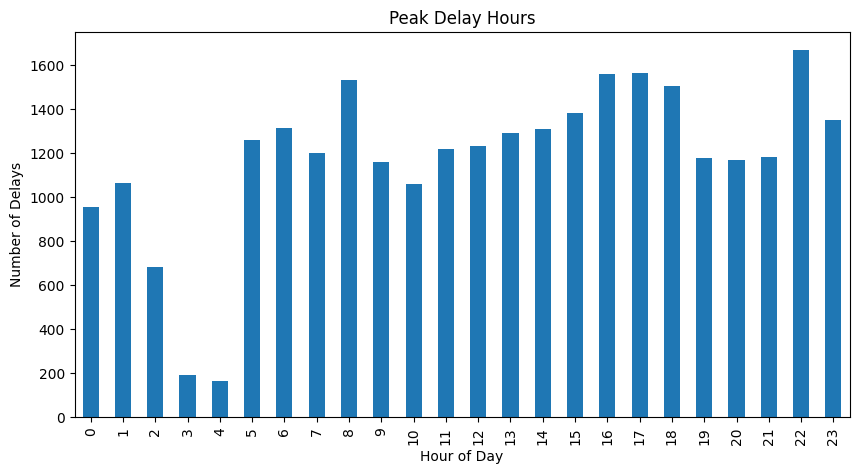

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df['hour'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))
plt.title("Peak Delay Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Delays")
plt.show()

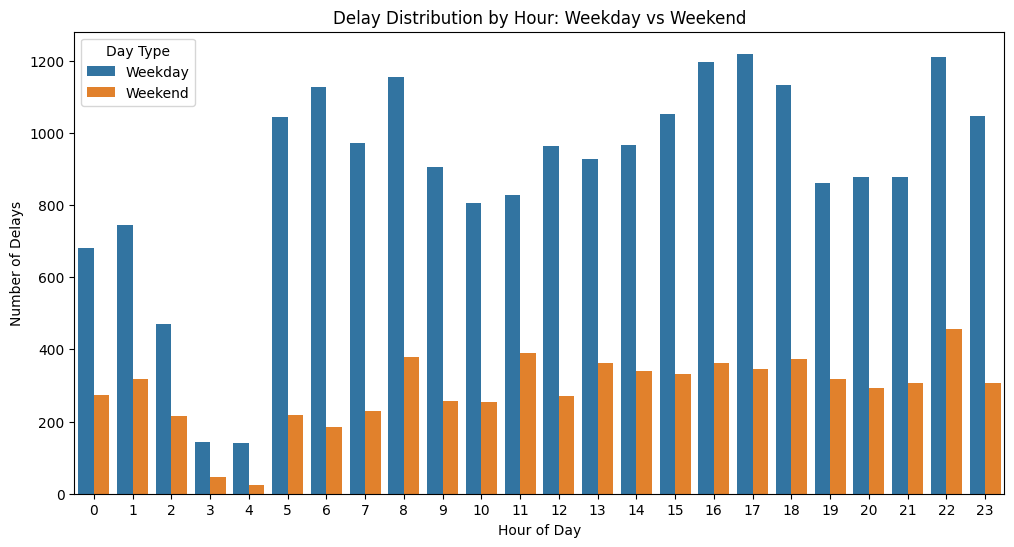

In [11]:
df['is_weekend'] = df['day_name'].isin(['Saturday', 'Sunday'])

plt.figure(figsize=(12,6))

sns.countplot(data=df, x='hour', hue='is_weekend')

plt.title("Delay Distribution by Hour: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Delays")
plt.legend(title="Day Type", labels=["Weekday", "Weekend"])

plt.show()

## 4. Where Delays Cluster

Next, the analysis moves from time to place. Lines, stations, and delay codes show whether the problem is concentrated around specific parts of the network or specific types of incidents.


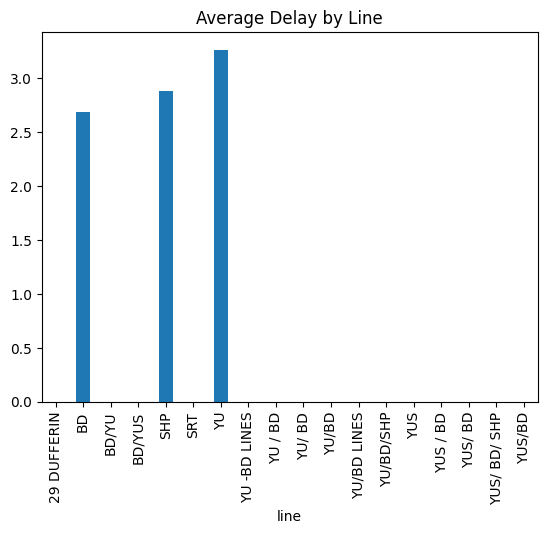

In [12]:
df.groupby('line')['min_delay'].mean().plot(kind='bar')
plt.title("Average Delay by Line")
plt.show()

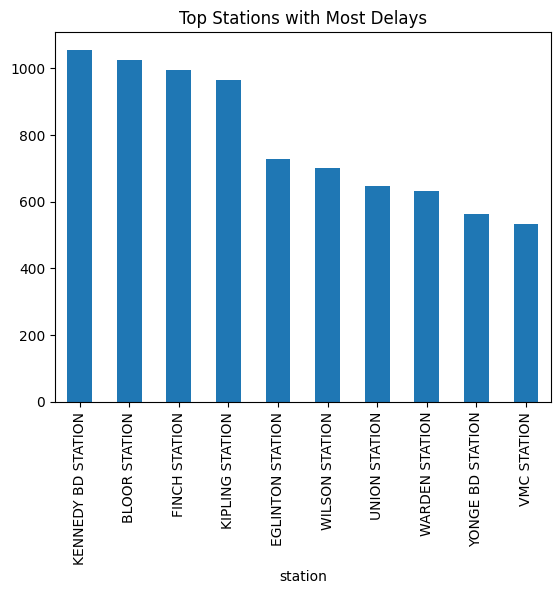

In [13]:
df['station'].value_counts().head(10).plot(kind='bar')
plt.title("Top Stations with Most Delays")
plt.show()

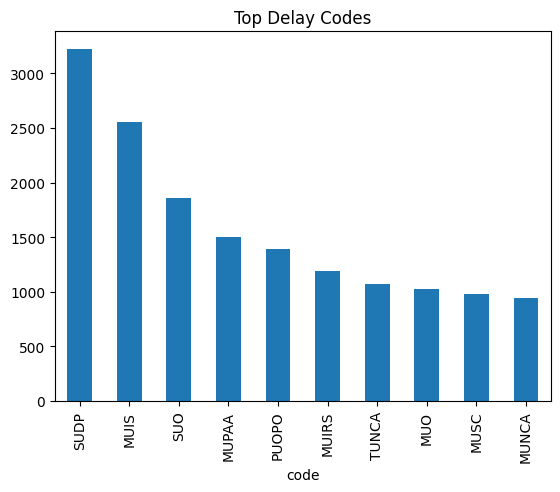

In [14]:
df['code'].value_counts().head(10).plot(kind='bar')
plt.title("Top Delay Codes")
plt.show()

## 5. Weather as Context

Weather is not the whole story, but it is useful context. Temperature and rainfall are checked against delay length to see whether rough weather lines up with longer disruptions.


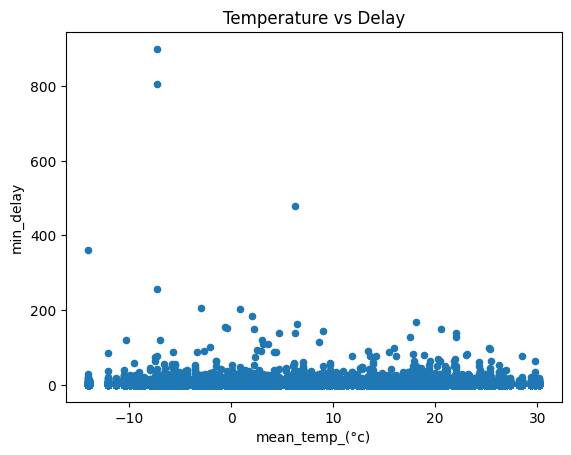

In [15]:
df.plot.scatter(x='mean_temp_(°c)', y='min_delay')
plt.title("Temperature vs Delay")
plt.show()

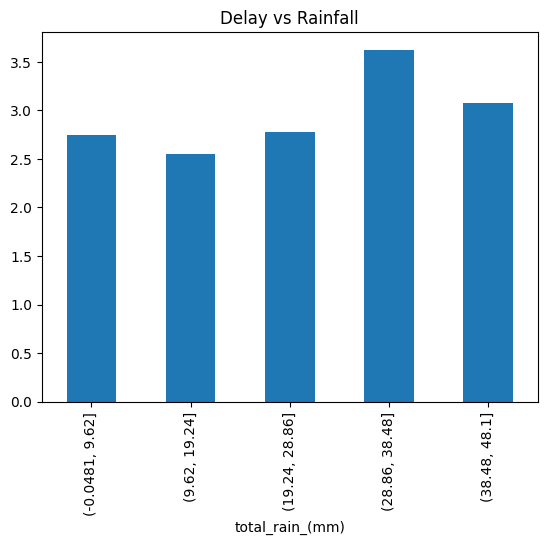

In [16]:
df.groupby(pd.cut(df['total_rain_(mm)'], bins=5))['min_delay'].mean().plot(kind='bar')
plt.title("Delay vs Rainfall")
plt.show()

## 6. Can We Predict Longer Delays?

For a simple first model, delays over 10 minutes are treated as the higher-impact group. Because these longer delays are uncommon, accuracy alone can be misleading, so the model is compared against a baseline and evaluated with precision, recall, and a confusion matrix.


In [17]:
df['delay_label'] = (df['min_delay'] > 10).astype(int)

df['delay_label'].value_counts(normalize=True).rename({0: '10 minutes or less', 1: 'over 10 minutes'})

delay_label
10 minutes or less    0.944911
over 10 minutes       0.055089
Name: proportion, dtype: float64

Model accuracy: 0.945
Baseline accuracy if every delay is predicted as 10 minutes or less: 0.945

Classification report:
                    precision    recall  f1-score   support

10 minutes or less       0.94      1.00      0.97      5328
   over 10 minutes       0.00      0.00      0.00       311

          accuracy                           0.94      5639
         macro avg       0.47      0.50      0.49      5639
      weighted avg       0.89      0.94      0.92      5639



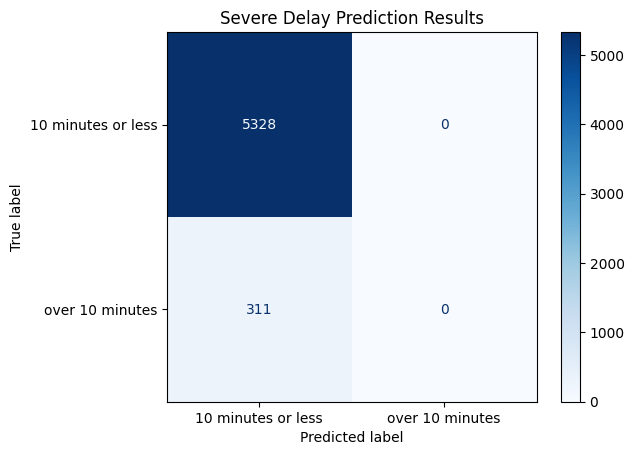

In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

features = ['hour', 'mean_temp_(°c)']
X = df[features].fillna(df[features].median())
y = df['delay_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
baseline_accuracy = (y_test == 0).mean()

print(f"Model accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Baseline accuracy if every delay is predicted as 10 minutes or less: {baseline_accuracy:.3f}")
print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['10 minutes or less', 'over 10 minutes'],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['10 minutes or less', 'over 10 minutes'],
    cmap='Blues'
)
plt.title('Severe Delay Prediction Results')
plt.show()

## Conclusion

The useful takeaway is not just whether a model can produce a high accuracy score. The analysis should show when delays are most common, which stations and lines carry the most incidents, and whether the model actually catches the rarer delays over 10 minutes. That final check is important because predicting every case as a short delay can look accurate while missing the events riders care about most.
